In [2]:
import pandas as pd
import os
import numpy as np
from dotenv import load_dotenv
from elasticsearch import Elasticsearch
from elasticsearch.helpers import bulk, scan
from umap import UMAP
import matplotlib.pyplot as plt

load_dotenv()  # Load API key from .env file

INDEX_NAME = "vectorhood"
OS_HOST = os.getenv("OS_HOST")
OS_API_KEY = os.getenv("OS_API_KEY")

client = Elasticsearch(
    hosts=[OS_HOST],
    api_key=OS_API_KEY
)


/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Build an embedding matrix
docs = []
for doc in scan(client, index=INDEX_NAME, query={
    "query": { "match_all": {} },
    }):
    source = doc["_source"]
    docs.append({
        "name": source.get("name", ""),
        "category": source.get("category", ""),
        "embedding": source["embedding"]
    })

docs_without_sentences = [doc for doc in docs if doc["category"].strip() != "Sentence"]

print("Number of documents in the index:", len(docs))
print("Number of documents without sentences:", len(docs_without_sentences))

# Convert to DataFrame
df = pd.DataFrame(docs)
embedding_matrix = np.array(df["embedding"].tolist())

df_wout_sentences = pd.DataFrame(docs_without_sentences)
embedding_matrix_wout_sentences = np.array(df_wout_sentences["embedding"].tolist())

print("Shape of embedding matrix:", embedding_matrix.shape)
print("Shape of embedding matrix (wout en):", embedding_matrix_wout_sentences.shape)

Number of documents in the index: 396
Number of documents without sentences: 387
Shape of embedding matrix: (396, 384)
Shape of embedding matrix (wout en): (387, 384)


In [4]:


# Reduce to 2D
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = umap_model.fit_transform(embedding_matrix_wout_sentences)
embedding_sentences_2d = umap_model.transform(embedding_matrix)

/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


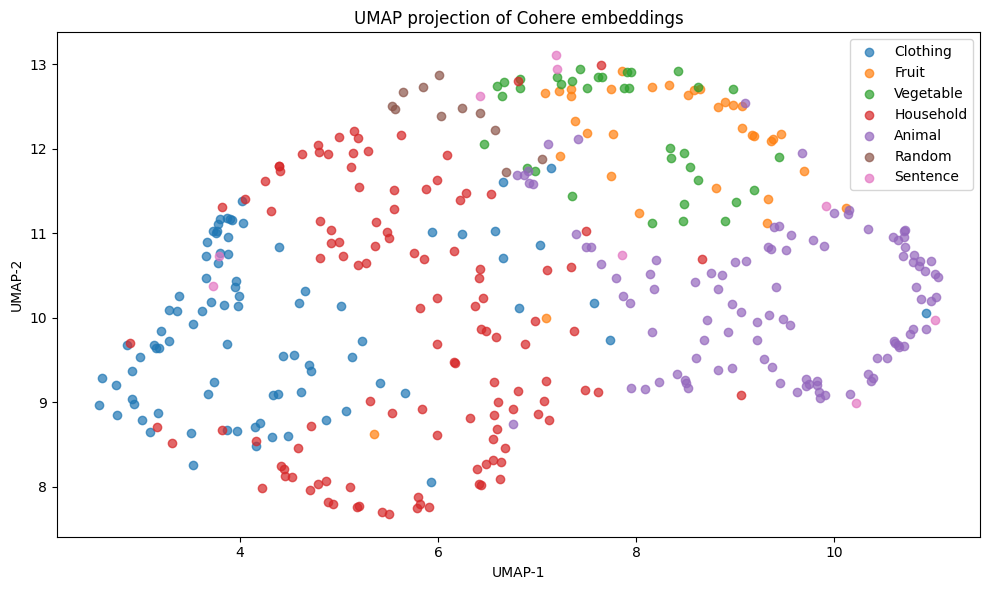

In [5]:
df["x"] = embedding_sentences_2d[:, 0]
df["y"] = embedding_sentences_2d[:, 1]

plt.figure(figsize=(10, 6))
for category in df["category"].unique():
    subset = df[df["category"] == category]
    plt.scatter(subset["x"], subset["y"], label=category, alpha=0.7)

plt.legend()
plt.title("UMAP projection of Cohere embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [6]:
from umap import UMAP

umap_model = UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
model = umap_model.fit(embedding_matrix_wout_sentences)
embedding_3d = umap_model.transform(embedding_matrix)
df["x"] = embedding_3d[:, 0]
df["y"] = embedding_3d[:, 1]
df["z"] = embedding_3d[:, 2]

/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lizozom/Projects/bdb/vectorhood/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Render all points

In [7]:
import plotly.express as px
import plotly.graph_objects as go

# Highlight specific points

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="category" if "category" in df.columns else None,
    opacity=0.7,
    hover_name="name",
    title="UMAP 3D Embedding Visualization"
)
fig.update_traces(marker=dict(size=3)) 
fig.update_layout(
    height=800,
    width=800,
    title=dict(
        text=None
    ),
    legend_title_text="",
    legend=dict(
        font=dict(size=24),
        itemsizing='constant',  
        itemwidth=40            
    )
)


fig.show()

## Highlight kiwi related embeddings

In [11]:
import plotly.express as px
import plotly.graph_objects as go

# Highlight specific points
highlight_kiwi_df = df[df["name"].str.contains("kiwi", case=False)]
highlight_tuxedo_df = df[df["name"].str.contains("tuxedo", case=False)]

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="category" if "category" in df.columns else None,
    opacity=0.7,
    hover_name="name",
    title="UMAP 3D Embedding Visualization"
)
fig.update_traces(marker=dict(size=3)) 
fig.update_layout(
    height=800,
    width=800,
    title=dict(
        text=None
    ),
    legend_title_text="",
    legend=dict(
        font=dict(size=24),
        itemsizing='constant',  
        itemwidth=40            
    )
)


fig.add_trace(go.Scatter3d(
    x=highlight_kiwi_df["x"],
    y=highlight_kiwi_df["y"],
    z=highlight_kiwi_df["z"],
    mode="markers+text",
    marker=dict(size=6, color="red", symbol="diamond"),
    text=highlight_kiwi_df["name"],
    textposition="middle right",  
    textfont=dict(size=18, color="black", family="Arial"),

    name="Kiwi"
))

fig.show()

## Highlight tuxedo related embeddings

In [12]:
import plotly.express as px
import plotly.graph_objects as go

# Highlight specific points

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="category" if "category" in df.columns else None,
    opacity=0.7,
    hover_name="name",
    title="UMAP 3D Embedding Visualization (Tuxedo)"
)
fig.update_traces(marker=dict(size=3)) 
fig.update_layout(
    height=800,
    width=800,
    legend=dict(
        font=dict(size=24),
        itemsizing='constant',  
        itemwidth=40            
    )
)

fig.add_trace(go.Scatter3d(
    x=highlight_tuxedo_df["x"],
    y=highlight_tuxedo_df["y"],
    z=highlight_tuxedo_df["z"],
    mode="markers+text",
    marker=dict(size=6, color="green", symbol="diamond"),
    text=highlight_tuxedo_df["name"],
    textposition="middle right", 
    textfont=dict(size=18, color="black", family="Arial"),
    name="Highlighted"
))
fig.show()